# 3D Persistent Homology — Fire Station Coverage × Heat Vulnerability Index
## Lifting the Point Cloud into (Easting, Northing, HVI) Space

### Core idea

Standard TDA uses 2D coordinates (x, y). Here we add **HVI as a third axis**,
lifting each fire station's coverage centroid into a 3D point:

```
p = (UTM_easting, UTM_northing, HVI_scaled)
```

A topological **hole** (H1 feature) in this 3D space means a region that is
simultaneously:
- **Geographically isolated** from fire stations (x, y gap)
- **High heat vulnerability** (elevated z)

These are the truest high-risk neighborhoods — not just spatially underserved,
but underserved *and* climatically vulnerable.

### What's new vs. the 2D notebooks
| | 2D PH notebooks | This notebook |
|---|---|---|
| Point cloud | (x, y) stations | (x, y, HVI) stations+tracts |
| Holes found | Geographic gaps | Geographic + vulnerability gaps |
| Visualization | Persistence diagram | **3D scatter + hole annotation** |
| Z-axis | — | HVI score (normalized) |

### Pipeline
1. Imports & config
2. Load all datasets
3. Assign HVI to census tracts → aggregate to neighborhoods
4. Build 3D point cloud: fire stations lifted by neighborhood HVI
5. Vietoris-Rips PH in 3D
6. Extract & visualise the simplicial complex in 3D
7. Plot H1 holes on 3D scatter
8. Draw holes back onto 2D geographic map
9. Neighborhood vulnerability table
10. Export

## Step 1 — Imports & Configuration

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import gudhi
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial.distance import pdist, squareform, cdist
from pyproj import Transformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
import matplotlib.cm as cm

# ── Paths ──
STATIONS_PATH  = "../../data/all_stations.geojson"
LA_COUNTY_PATH = "../../data/la_county.geojson"
HVI_PATH       = "../../data/HVI_LACounty.csv"

CRS_WGS84 = "EPSG:4326"
CRS_UTM   = "EPSG:32611"

# ── 3D filtration ceiling ──
# x, y are in metres; z is HVI scaled to metres-equivalent
# 15 km covers most inter-station gaps at county scale
RIPS_MAX_M = 15_000

# ── HVI z-axis scaling ──
# HVI ranges 5–91. We scale it so the z-range is comparable to x,y spread.
# LA County is ~120 km wide — we want z-range ≈ 20–30% of that = 25–35 km.
# Scaling factor: target_z_range / hvi_range ≈ 30000 / 85 ≈ 350
HVI_SCALE = 350   # metres per HVI unit

# ── H1 significance threshold (metres in 3D space) ──
H1_THRESH_M = 2_000

# ── Evaluation radii ──
EVAL_RADII_M = [2000, 4000, 6000, 8000, 10000, 15000]

print("Configuration loaded.")

Configuration loaded.


## Step 2 — Load All Datasets

In [4]:
la_county = gpd.read_file(LA_COUNTY_PATH).set_crs(CRS_WGS84, allow_override=True)
stations  = gpd.read_file(STATIONS_PATH).set_crs(CRS_WGS84, allow_override=True)
hvi_df    = pd.read_csv(HVI_PATH)

print(f"Neighborhoods : {len(la_county)}")
print(f"Stations      : {len(stations)}")
print(f"HVI tracts    : {len(hvi_df)}  (null HVI: {hvi_df['hvi'].isna().sum()})")
print(f"HVI range     : {hvi_df['hvi'].min():.2f} – {hvi_df['hvi'].max():.2f}")
hvi_df.head(3)

Neighborhoods : 272
Stations      : 412
HVI tracts    : 2344  (null HVI: 19)
HVI range     : 5.44 – 90.81


,census_tract,census_county,census_city,hvi
0,6037101110,Los Angeles County,Tujunga,36.53
1,6037101122,Los Angeles County,Tujunga,19.76
2,6037101210,Los Angeles County,Tujunga,43.45


## Step 3 — Assign HVI to Neighborhoods

The HVI dataset is at **census-tract level**; our analysis is at
**neighborhood level**. We aggregate by matching `census_city` to
neighborhood names, then fall back to spatial join via tract centroids.

Steps:
1. Direct name match: `census_city` → neighborhood `name`
2. Unmatched neighborhoods: assign county median HVI
3. Final result: one HVI score per neighborhood

In [5]:
# Drop nulls
hvi_clean = hvi_df.dropna(subset=["hvi"]).copy()

# ── Aggregate HVI per city (median across tracts) ──
hvi_by_city = (
    hvi_clean.groupby("census_city")["hvi"]
    .median()
    .reset_index()
    .rename(columns={"census_city": "name", "hvi": "hvi_median"})
)

# ── Merge onto neighborhoods ──
la_county = la_county.merge(hvi_by_city, on="name", how="left")

# ── Fill unmatched with county median ──
county_median = hvi_clean["hvi"].median()
la_county["hvi_median"] = la_county["hvi_median"].fillna(county_median)

matched   = la_county["hvi_median"].notna().sum()
filled    = (la_county["hvi_median"] == county_median).sum()
print(f"Neighborhoods with direct HVI match : {matched - filled}")
print(f"Neighborhoods filled with median    : {filled}")
print(f"County median HVI                   : {county_median:.2f}")
la_county[["name", "hvi_median"]].sort_values("hvi_median", ascending=False).head(10)

Neighborhoods with direct HVI match : 109
Neighborhoods filled with median    : 163
County median HVI                   : 42.72


,name,hvi_median
168,Panorama City,60.510
107,Huntington Park,58.910
145,Maywood,58.250
50,Compton,57.740
268,Wilmington,56.920
110,Inglewood,55.855
164,Pacoima,53.400
99,Hawthorne,53.380
208,South El Monte,52.350
98,Hawaiian Gardens,51.930


## Step 4 — Build the 3D Point Cloud

For each fire station we compute its **3D coordinates**:
- `x, y` = UTM easting/northing (metres) of the station
- `z` = HVI of the neighborhood the station sits in × `HVI_SCALE`

Then we add **neighborhood centroids** as additional points (weighted by HVI)
so the filtration captures the full geographic extent of each vulnerability zone,
not just the station locations.

In [7]:
# ── Clip & project stations ──
county_boundary = unary_union(la_county.geometry)
stations_clip   = stations[stations.geometry.within(county_boundary)].copy()
stations_proj   = stations_clip.to_crs(CRS_UTM).reset_index(drop=True)
county_proj     = la_county.to_crs(CRS_UTM)

coords_2d = np.column_stack([stations_proj.geometry.x,
                               stations_proj.geometry.y])

# ── Spatial join: which neighborhood is each station in? ──
stations_proj["geometry_pt"] = stations_proj.geometry
sj = gpd.sjoin(
    stations_proj,
    county_proj[["name", "hvi_median", "geometry"]],
    how="left", predicate="within"
).rename(columns={"name": "neighborhood", "hvi_median": "hvi"})

sj["hvi"] = sj["hvi"].fillna(county_median)

# ── 3D coordinates: (x, y, hvi * scale) ──
coords_3d_stations = np.column_stack([
    sj.geometry.x,
    sj.geometry.y,
    sj["hvi"].values * HVI_SCALE
])

# ── Also add neighborhood centroids as 3D points ──
county_proj["cx"] = county_proj.geometry.centroid.x
county_proj["cy"] = county_proj.geometry.centroid.y

coords_3d_hoods = np.column_stack([
    county_proj["cx"].values,
    county_proj["cy"].values,
    county_proj["hvi_median"].values * HVI_SCALE
])

# ── Combined 3D point cloud ──
coords_3d = np.vstack([coords_3d_stations, coords_3d_hoods])
source_labels = (
    ["station"] * len(coords_3d_stations) +
    ["neighborhood"] * len(coords_3d_hoods)
)

print(f"3D point cloud:")
print(f"  Station points      : {len(coords_3d_stations)}")
print(f"  Neighborhood points : {len(coords_3d_hoods)}")
print(f"  Total               : {len(coords_3d)}")
print(f"  x range (km)        : {np.ptp(coords_3d[:,0])/1000:.1f}")
print(f"  y range (km)        : {np.ptp(coords_3d[:,1])/1000:.1f}")
print(f"  z range (HVI×scale) : {np.ptp(coords_3d[:,2])/1000:.1f} km-equivalent")

3D point cloud:
  Station points      : 410
  Neighborhood points : 272
  Total               : 682
  x range (km)        : 108.6
  y range (km)        : 158.7
  z range (HVI×scale) : 17.1 km-equivalent


## Step 5 — Vietoris-Rips Persistent Homology in 3D

Same Rips filtration as before, but now on the **3D point cloud**.
A hole (H1 feature) in 3D means a loop that cannot be contracted —
geographically a region both spatially isolated from stations *and*
elevated in the HVI dimension (high vulnerability).

In [8]:
print(f"Building 3D Rips complex: N={len(coords_3d)}, max_ε={RIPS_MAX_M/1000:.0f} km ...")

rips_3d = gudhi.RipsComplex(points=coords_3d, max_edge_length=RIPS_MAX_M)
st_3d   = rips_3d.create_simplex_tree(max_dimension=2)

print(f"  Simplices : {st_3d.num_simplices():,}")
print(f"  Vertices  : {st_3d.num_vertices():,}")

st_3d.compute_persistence(homology_coeff_field=2, min_persistence=0)
print("Persistence computed.")

def extract_diagrams(st):
    H0, H0_inf, H1, H1_inf = [], [], [], []
    for dim, (b, d) in st.persistence():
        if   dim == 0: (H0_inf if np.isinf(d) else H0).append((b, d))
        elif dim == 1: (H1_inf if np.isinf(d) else H1).append((b, d))
    return {"H0": H0, "H0_inf": H0_inf, "H1": H1, "H1_inf": H1_inf}

diag_3d = extract_diagrams(st_3d)
print(f"H0 finite : {len(diag_3d['H0'])}   H0 essential : {len(diag_3d['H0_inf'])}")
print(f"H1 finite : {len(diag_3d['H1'])}   H1 essential : {len(diag_3d['H1_inf'])}")

Building 3D Rips complex: N=682, max_ε=15 km ...
  Simplices : 960,017
  Vertices  : 682
Persistence computed.
H0 finite : 677   H0 essential : 4
H1 finite : 185   H1 essential : 2


## Step 6 — 3D Simplicial Complex Visualisation

Draw the Rips complex at a chosen ε value in 3D space.
- **Points** coloured by HVI (blue = low vulnerability, red = high)
- **Edges** = pairs within distance ε
- **Triangles** = filled 2-simplices showing covered regions

The **empty regions** (holes) in the mesh are the H1 features.

At ε = 6.0 km:  edges=5,043  triangles=20,693
Saved: 3d_complex_6km.png


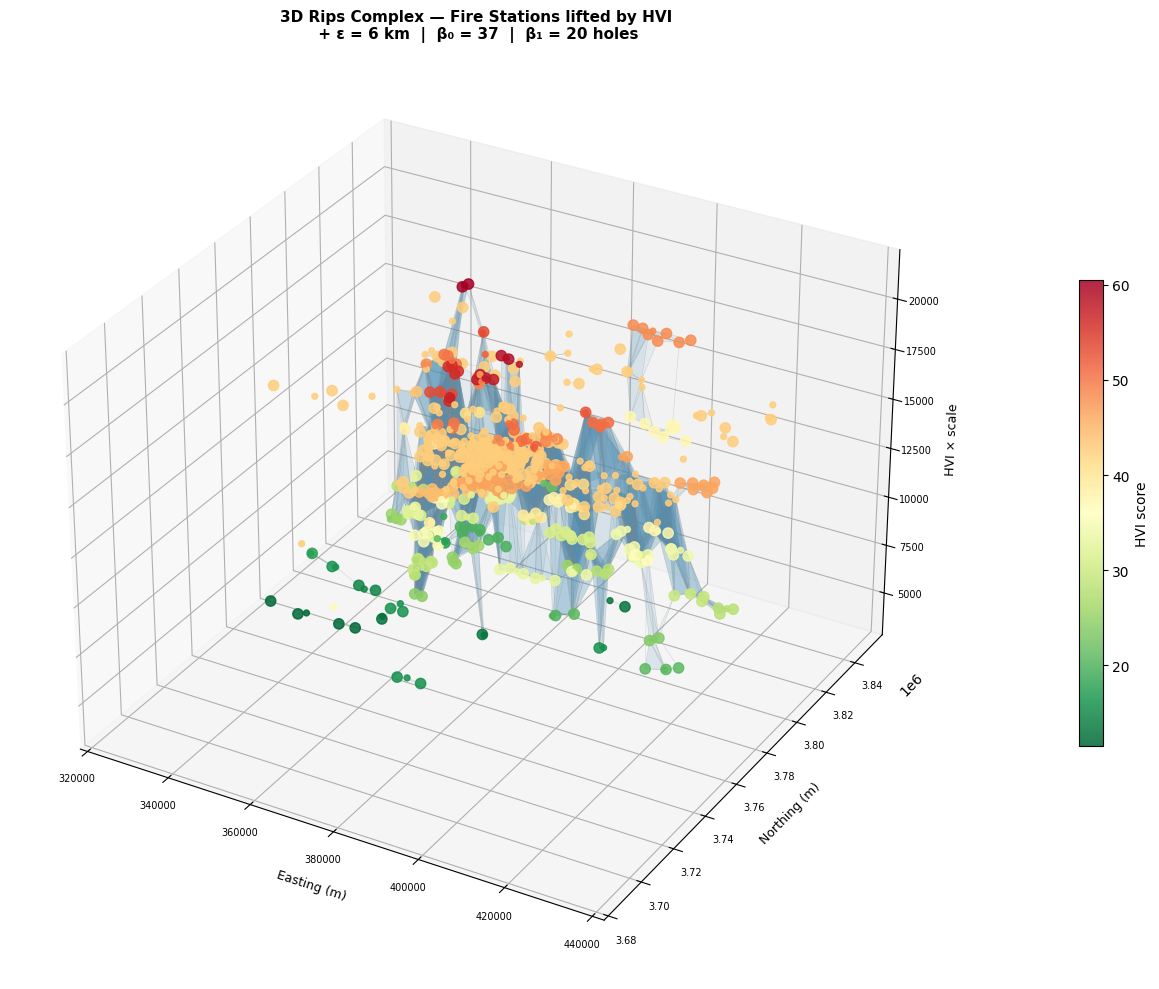

At ε = 10.0 km:  edges=15,194  triangles=186,831
Saved: 3d_complex_10km.png


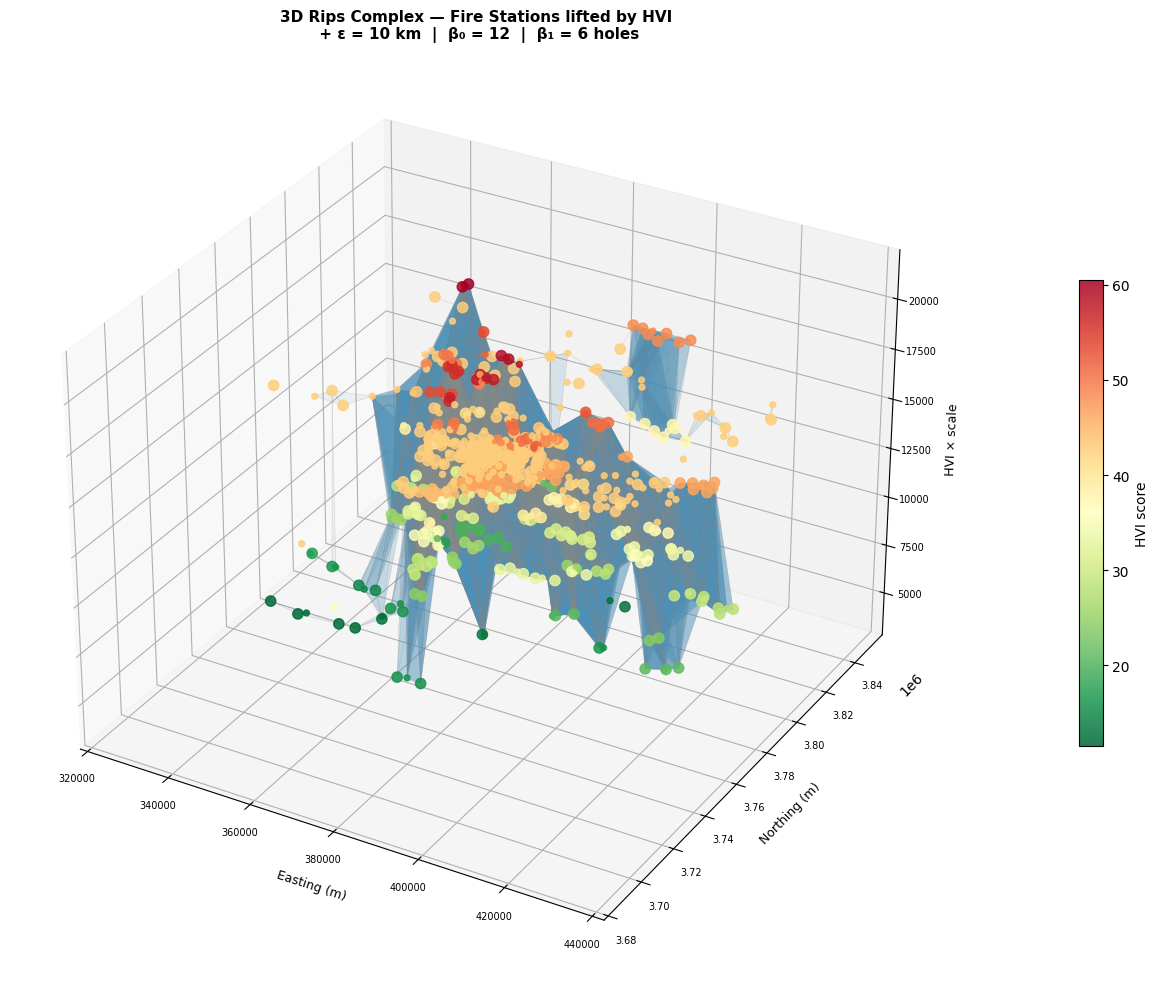

In [11]:
def plot_3d_simplicial_complex(coords_3d, simplex_tree, epsilon_m,
                                source_labels, hvi_scale=HVI_SCALE,
                                title="", out_path=None):
    """
    Render the Rips complex R(X, ε) in 3D.

    x, y = geographic (UTM metres)
    z    = HVI × HVI_SCALE

    Color encodes HVI level (z-axis).
    Station points are rendered as larger markers than neighborhood centroids.
    """
    # Collect simplices alive at epsilon
    edges, tris = [], []
    for simplex, fval in simplex_tree.get_filtration():
        if fval > epsilon_m:
            continue
        if len(simplex) == 2:
            edges.append(simplex)
        elif len(simplex) == 3:
            tris.append(simplex)

    print(f"At ε = {epsilon_m/1000:.1f} km:  "
          f"edges={len(edges):,}  triangles={len(tris):,}")

    # ── Betti numbers ──
    b0 = (sum(1 for b,d in diag_3d["H0"]     if b <= epsilon_m <= d) +
          sum(1 for b,d in diag_3d["H0_inf"] if epsilon_m >= b))
    b1 = (sum(1 for b,d in diag_3d["H1"]     if b <= epsilon_m <= d) +
          sum(1 for b,d in diag_3d.get("H1_inf",[]) if epsilon_m >= b))

    fig = plt.figure(figsize=(14, 10))
    ax  = fig.add_subplot(111, projection="3d")

    hvi_vals = coords_3d[:, 2] / hvi_scale
    norm     = plt.Normalize(vmin=hvi_vals.min(), vmax=hvi_vals.max())
    cmap     = cm.RdYlGn_r

    # ── 2-simplices (triangles) ──
    if tris:
        tri_verts = [
            [coords_3d[i], coords_3d[j], coords_3d[k]]
            for i, j, k in tris
        ]
        tri_col = Poly3DCollection(tri_verts, alpha=0.08,
                                    facecolor="#4a90b8", edgecolor="none")
        ax.add_collection3d(tri_col)

    # ── 1-simplices (edges) ──
    if edges:
        edge_verts = [[coords_3d[i], coords_3d[j]] for i, j in edges]
        ec = Line3DCollection(edge_verts, colors="#888", linewidths=0.4,
                              alpha=0.3)
        ax.add_collection3d(ec)

    # ── 0-simplices (points) coloured by HVI ──
    labels = np.array(source_labels)
    for src, size, zorder in [("neighborhood", 18, 3), ("station", 55, 5)]:
        mask = labels == src
        sc = ax.scatter(
            coords_3d[mask, 0], coords_3d[mask, 1], coords_3d[mask, 2],
            c=hvi_vals[mask], cmap=cmap, norm=norm,
            s=size, alpha=0.85, zorder=zorder,
            depthshade=True
        )

    plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.1, label="HVI score")

    ax.set_xlabel("Easting (m)",  fontsize=9, labelpad=6)
    ax.set_ylabel("Northing (m)", fontsize=9, labelpad=6)
    ax.set_zlabel("HVI × scale",  fontsize=9, labelpad=6)
    ax.set_title(
        f"{title}\n + "
        f"ε = {epsilon_m/1000:.0f} km  |  β₀ = {b0}  |  β₁ = {b1} holes",
        fontsize=11, fontweight="bold"
    )
    ax.tick_params(labelsize=7)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {out_path}")
    plt.show()


# ── Plot at two epsilon values ──
for eps in [6_000, 10_000]:
    plot_3d_simplicial_complex(
        coords_3d, st_3d, eps,
        source_labels,
        title=f"3D Rips Complex — Fire Stations lifted by HVI",
        out_path=f"3d_complex_{eps//1000}km.png"
    )

## Step 7 — Persistence Diagram & Barcode (3D)

Same plots as the 2D notebooks but now each H1 bar corresponds to a
3D hole — a region that is both geographically and vulnerably isolated.

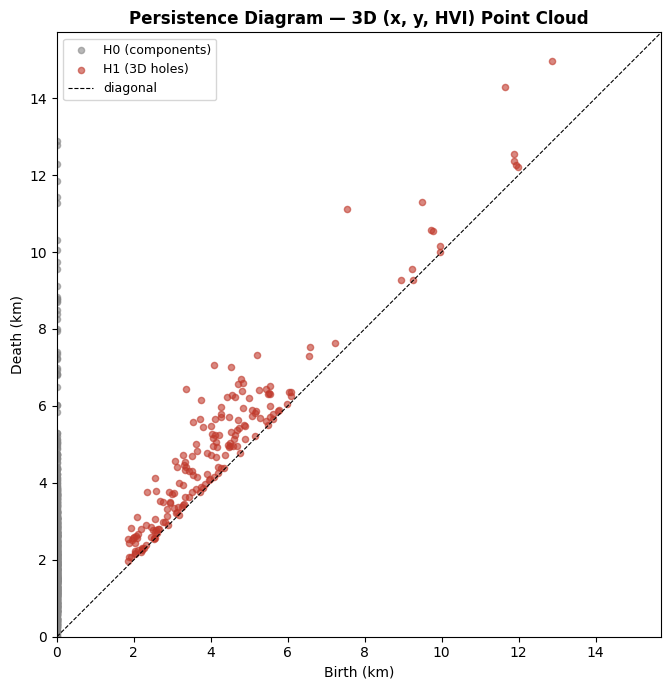

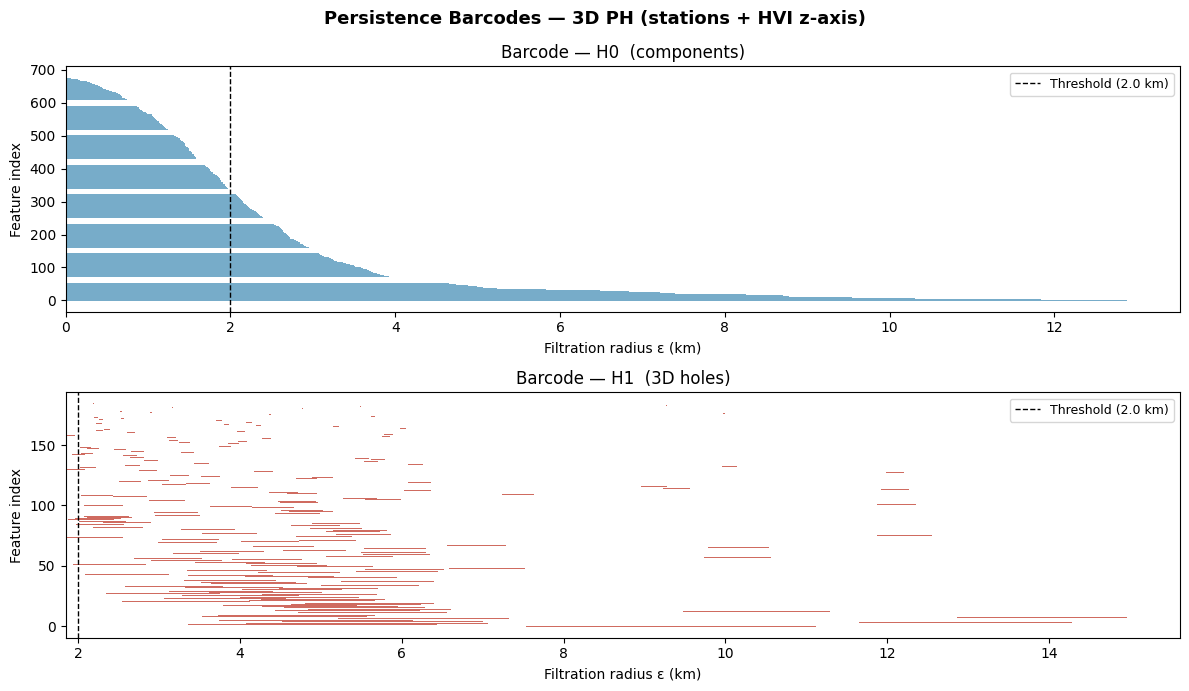

In [13]:
# ── Persistence diagram ──
fig, ax = plt.subplots(figsize=(8, 7))

for key, color, label in [
    ("H0", "#888888", "H0 (components)"),
    ("H1", "#c0392b", "H1 (3D holes)"),
]:
    pairs = diag_3d[key]
    if pairs:
        arr = np.array(pairs)
        ax.scatter(arr[:,0]/1000, arr[:,1]/1000,
                   c=color, alpha=0.6, s=20, label=label)

all_pairs = diag_3d["H0"] + diag_3d["H1"]
lim = max((d for _, d in all_pairs if not np.isinf(d)),
           default=RIPS_MAX_M) / 1000 * 1.05

ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="diagonal")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Birth (km)"); ax.set_ylabel("Death (km)")
ax.set_title("Persistence Diagram — 3D (x, y, HVI) Point Cloud",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("3d_persistence_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Barcode ──
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, key, color in zip(axes,
                           ["H0", "H1"],
                           ["#4a90b8", "#c0392b"]):
    pairs = sorted(diag_3d[key], key=lambda x: x[1]-x[0], reverse=True)
    for i, (b, d) in enumerate(pairs):
        ax.barh(i, (d-b)/1000, left=b/1000,
                color=color, alpha=0.75, height=0.8)
    ax.axvline(H1_THRESH_M/1000, color="black", linestyle="--", lw=1,
               label=f"Threshold ({H1_THRESH_M/1000:.1f} km)")
    ax.set_xlabel("Filtration radius ε (km)")
    ax.set_ylabel("Feature index")
    ax.set_title(f"Barcode — {key}  ({'components' if key=='H0' else '3D holes'})")
    ax.legend(fontsize=9)

plt.suptitle("Persistence Barcodes — 3D PH (stations + HVI z-axis)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("3d_barcodes.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Project H1 Holes Back onto 2D Geographic Map

Each significant H1 void is drawn as a circle on the LA County map,
coloured by the average HVI of that void region.
This is the key output: **where are the high-vulnerability coverage gaps?**

In [14]:
def find_void_centre_3d(birth, death, coords_3d, county_proj,
                          grid_step_m=2000):
    """
    Find the (x, y) geographic centre of a 3D H1 void.

    We search for the grid point (inside the county) whose 3D distance
    to the nearest point in coords_3d falls within [birth, death].
    """
    county_union = unary_union(county_proj.geometry)
    minx, miny, maxx, maxy = county_union.bounds
    gx = np.arange(minx, maxx, grid_step_m)
    gy = np.arange(miny, maxy, grid_step_m)
    GX, GY   = np.meshgrid(gx, gy)
    grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
    inside   = np.array([county_union.contains(Point(p)) for p in grid_pts])
    grid_in  = grid_pts[inside]

    # Lift grid points to 3D using average HVI at each location
    # (use county median as proxy — grid points aren't real stations)
    hvi_mean_z = coords_3d[:, 2].mean()
    grid_3d    = np.column_stack([
        grid_in,
        np.full(len(grid_in), hvi_mean_z)
    ])

    # Chunked distance to nearest 3D point
    chunk, D_min = 500, np.full(len(grid_3d), np.inf)
    for s in range(0, len(grid_3d), chunk):
        e = min(s + chunk, len(grid_3d))
        D_min[s:e] = cdist(grid_3d[s:e], coords_3d).min(axis=1)

    mid  = (birth + death) / 2
    tol  = (death - birth) * 0.4
    mask = (D_min >= mid - tol) & (D_min <= mid + tol)
    cands = grid_in[mask] if mask.any() else grid_in

    cands_3d = np.column_stack([cands, np.full(len(cands), hvi_mean_z)])
    D2       = cdist(cands_3d, coords_3d).min(axis=1)
    return grid_in[np.argmax(D2)]


# ── Significant H1 voids ──
sig_h1 = [(b, d, d-b) for b, d in diag_3d["H1"] if (d-b) >= H1_THRESH_M]
sig_h1.sort(key=lambda x: -x[2])
print(f"Significant H1 voids (persistence ≥ {H1_THRESH_M/1000:.1f} km): {len(sig_h1)}")

# ── Localise voids ──
void_rows = []
t_back = Transformer.from_crs(CRS_UTM, CRS_WGS84, always_xy=True)

for rank, (birth, death, pers) in enumerate(sig_h1, 1):
    centre_m = find_void_centre_3d(birth, death, coords_3d, county_proj)
    cx, cy   = centre_m
    lon, lat = t_back.transform(cx, cy)

    # Average HVI of nearby points
    d_to_centre = np.sqrt(((coords_3d[:, :2] - centre_m)**2).sum(1))
    nearby_hvi  = (coords_3d[:, 2] / HVI_SCALE)[d_to_centre <= death]
    avg_hvi     = nearby_hvi.mean() if len(nearby_hvi) > 0 else county_median

    hood = "Outside named neighborhoods"
    for _, row in county_proj.iterrows():
        if row.geometry.contains(Point(cx, cy)):
            hood = row.get("name", "Unknown")
            break

    void_rows.append({
        "rank"         : rank,
        "birth_m"      : round(birth, 0),
        "death_m"      : round(death, 0),
        "persistence_m": round(pers, 0),
        "avg_hvi"      : round(avg_hvi, 2),
        "neighborhood" : hood,
        "void_lon"     : round(lon, 5),
        "void_lat"     : round(lat, 5),
    })

void_df = pd.DataFrame(void_rows)
print(void_df[["rank","neighborhood","persistence_m","avg_hvi"]].to_string(index=False))

Significant H1 voids (persistence ≥ 2.0 km): 9
 rank                   neighborhood  persistence_m  avg_hvi
    1               Santa Fe Springs         3580.0    42.34
    2            Chesterfield Square         3082.0    44.21
    3                Manhattan Beach         2995.0    36.70
    4                     Long Beach         2629.0    45.66
    5                         Walnut         2488.0    32.45
    6                       Torrance         2400.0    38.10
    7            Chesterfield Square         2120.0    43.98
    8 Unincorporated Catalina Island         2101.0    39.77
    9                       Industry         2047.0    29.02


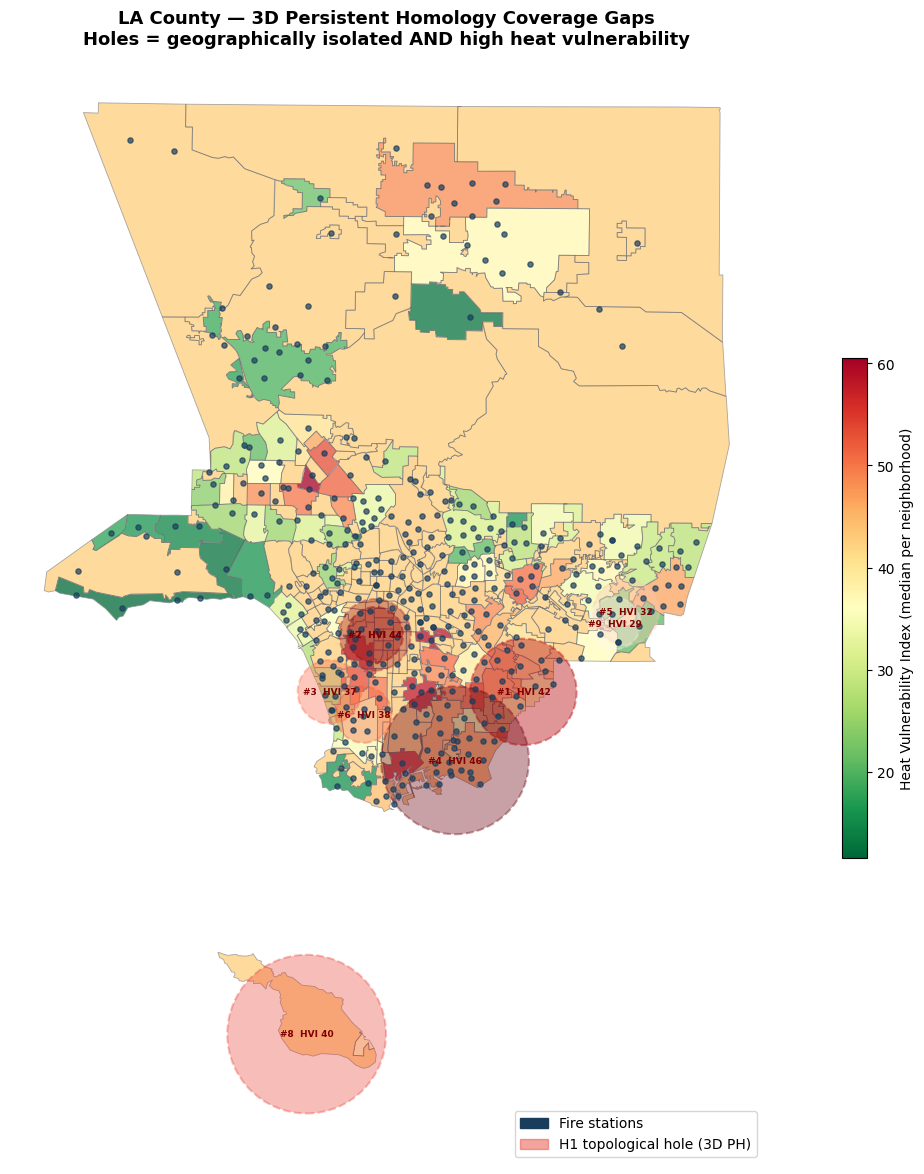

Saved: 3d_ph_holes_map.png


In [18]:
# ── 2D map with H1 holes annotated ──
fig, ax = plt.subplots(figsize=(16, 12))

# Neighborhood choropleth by HVI
county_proj.plot(
    column="hvi_median", ax=ax,
    cmap="RdYlGn_r", edgecolor="white", linewidth=0.3,
    alpha=0.75, legend=True,
    legend_kwds={"label": "Heat Vulnerability Index (median per neighborhood)",
                 "shrink": 0.45}
)

# Station points
ax.scatter(coords_3d_stations[:, 0], coords_3d_stations[:, 1],
           c="#1a3d5c", s=14, alpha=0.7, zorder=5, label="Fire station")

# H1 void circles — coloured by HVI severity
if len(void_df) > 0:
    hvi_norm = plt.Normalize(void_df["avg_hvi"].min(),
                              void_df["avg_hvi"].max())
    cmap_voids = cm.Reds

    for _, row in void_df.iterrows():
        lon, lat = row["void_lon"], row["void_lat"]
        cx_utm, cy_utm = Transformer.from_crs(
            CRS_WGS84, CRS_UTM, always_xy=True
        ).transform(lon, lat)

        radius = (row["birth_m"] + row["death_m"]) / 2
        color  = cmap_voids(hvi_norm(row["avg_hvi"]))
        alpha  = 0.15 + 0.30 * (row["persistence_m"] / void_df["persistence_m"].max())

        circle = plt.Circle((cx_utm, cy_utm), radius,
                             color=color, fill=True, alpha=alpha,
                             linewidth=1.5, linestyle="--",
                             zorder=4)
        ax.add_patch(circle)

        if row["rank"] <= 12:
            ax.annotate(
                f"#{row['rank']}  HVI {row['avg_hvi']:.0f}",
                xy=(cx_utm, cy_utm), ha="center", va="center",
                fontsize=6.5, color="#7f0000", fontweight="bold", zorder=6
            )

county_proj.boundary.plot(ax=ax, color="#555", linewidth=0.6, alpha=0.5)

patches = [
    mpatches.Patch(color="#1a3d5c", label="Fire stations"),
    mpatches.Patch(color="#e74c3c", alpha=0.5,
                   label="H1 topological hole (3D PH)"),
]
ax.legend(handles=patches, fontsize=10, loc="lower right")
ax.set_title(
    f"LA County — 3D Persistent Homology Coverage Gaps\n"+
    f"Holes = geographically isolated AND high heat vulnerability",
    fontsize=13, fontweight="bold"
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("3d_ph_holes_map.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: 3d_ph_holes_map.png")

## Step 9 — Neighborhood Vulnerability Table

Combine HVI score with topological gap metrics for each neighborhood.

The final score penalizes neighborhoods that are **both** far from stations
and have high HVI — the two conditions are multiplicative, not additive.

In [19]:
def n01(s):
    r = s.max() - s.min()
    return (s - s.min()) / r if r > 0 else s * 0

rows = []
for _, row in county_proj.iterrows():
    cx, cy    = row.geometry.centroid.x, row.geometry.centroid.y
    centroid  = np.array([cx, cy, row["hvi_median"] * HVI_SCALE])
    dists_3d  = np.sqrt(((coords_3d - centroid)**2).sum(1))
    min_d     = dists_3d.min()
    local_b1  = sum(1 for b, d in diag_3d["H1"] if b <= min_d <= d)

    # 2D distance to nearest station (geographic only)
    dists_2d  = np.sqrt(((coords_3d_stations[:, :2] - [cx, cy])**2).sum(1))
    min_2d    = dists_2d.min()

    rows.append({
        "neighborhood"    : row.get("name", "Unknown"),
        "hvi_median"      : round(row["hvi_median"], 2),
        "min_3d_dist_m"   : round(min_d, 0),
        "min_2d_dist_km"  : round(min_2d / 1000, 3),
        "local_beta1_3d"  : local_b1,
    })

vuln = pd.DataFrame(rows)

# Composite: geographic gap × HVI penalty
vuln["hvi_gap_score"] = (
    0.50 * n01(vuln["min_2d_dist_km"]) +
    0.30 * n01(vuln["local_beta1_3d"]) +
    0.20 * n01(vuln["hvi_median"])
).round(4)

# Multiplicative penalty: score is amplified for high-HVI neighborhoods
vuln["hvi_penalized_score"] = (
    vuln["hvi_gap_score"] * (1 + n01(vuln["hvi_median"]))
).round(4)

vuln = vuln.sort_values("hvi_penalized_score", ascending=False).reset_index(drop=True)
vuln.index += 1

print("Top 20 most vulnerable neighborhoods (3D PH + HVI penalty):")
vuln.head(20)[["neighborhood", "hvi_median", "min_2d_dist_km",
               "local_beta1_3d", "hvi_penalized_score"]]

Top 20 most vulnerable neighborhoods (3D PH + HVI penalty):


,neighborhood,hvi_median,min_2d_dist_km,local_beta1_3d,hvi_penalized_score
1,Unincorporated Catalina Island,42.72,39.329,0,0.9604
2,Avalon,36.82,42.790,0,0.9146
3,Angeles Crest,42.72,16.072,0,0.5147
4,Tujunga Canyons,42.72,12.339,0,0.4432
5,Panorama City,60.51,1.221,0,0.4264
6,Huntington Park,58.91,0.838,0,0.3978
7,Maywood,58.25,1.012,0,0.3937
8,Ridge Route,42.72,9.736,0,0.3933
9,Northwest Antelope Valley,42.72,9.549,0,0.3897
10,Northeast Antelope Valley,42.72,8.958,0,0.3784


## Step 10 — Export

In [ ]:
void_df.to_csv("3d_ph_voids.csv", index=False)
vuln.to_csv("3d_ph_neighborhood_vulnerability.csv", index=False)

print("Exported:")
print("  3d_ph_voids.csv                      — H1 holes with HVI + location")
print("  3d_ph_neighborhood_vulnerability.csv — ranked neighborhoods")
print("  3d_persistence_diagram.png")
print("  3d_barcodes.png")
print(f"  3d_complex_6km.png  / 3d_complex_10km.png")
print("  3d_ph_holes_map.png                  — 2D map with holes annotated")